# Paddy yield prediction with a Gradient Boosting Regressor (F1000Research 11:682)

**Paper:** D.S. Riza et al., *"Remote sensing and machine learning for yield prediction of lowland paddy crops"*, F1000Research 11:682, 2022. DOI: [10.12688/f1000research.110608.1](https://doi.org/10.12688/f1000research.110608.1)

**Author code:** [`lala-s-riza/Remote-sensing-and-machine-learning-for-yield-prediction-of-lowland-paddy-crops`](https://github.com/lala-s-riza/Remote-sensing-and-machine-learning-for-yield-prediction-of-lowland-paddy-crops) — pinned commit `cb760d834478173025b25290367dc271b263b792` (code shipped as `Program Python.zip`; also archived on Zenodo record 6459715, v1.0.0, license "other-open").

**Data:** [`Dataset Final.xlsx` on OSF registration p9cy3](https://osf.io/p9cy3/) (sha256 `36bdd08d520025668417804e1aa5bbe5e7fd8c96a8bf1f29e5e9bd99af4fc207`).

## Scope and execution status (English)

This notebook reproduces the paper's **best model scenario** (Table 6, scenario 75): train the authors' own Gradient Boosting Regressor implementation on their 267-row dataset (`NDVI`, total pixels, one-hot harvest period, temperature, planted area → yield in quintal) with `estimators=2000, learning_rate=0.001, min_samples_split=2, max_depth=4`, an 80/20 shuffled train/test split, and StandardScaler standardization, then recompute the RMSE and compare it with the reported **9766.72 quintal**.

**Not reproduced here** (stated explicitly): the ENVI remote-sensing pipeline (Landsat 8 download, cloud masking, atmospheric correction, stratified sampling) that produced the dataset — it requires ENVI software and EarthExplorer credentials. We start from the paper's published, processed dataset. The 90-scenario parameter sweep is also omitted; only the winning configuration is run.

**Adaptations (documented, behavior-preserving or explicit):**
1. The released `main.py` shuffles the split without a seed; we pass a fixed seed for reproducibility (same `train_test_split` function, same 214/53 sizes).
2. The authors' `divide_by_threshold` uses Python list comprehensions, which is too slow for 2000 trees; we vectorize it with NumPy and **assert exact equality** against the original on test data. All other author code is used unmodified.
3. `main.py` defaults to scenario `200/0.1/2/4`; we use the paper's best scenario `2000/0.001/2/4`.

**実行ステータス（日本語）:** このノートブックは、F1000Research 11:682（低地パディ収量予測）の最良シナリオ（推定器2000・学習率0.001・深さ4・min_split2）を著者自身の実装で再学習し、RMSE を報告値 9766.72 と比較します。ENVI による衛星画像前処理（ Landsat 8 取得・大気補正・層化サンプリング）は対象外で、公開済みの処理後データセットから開始します。分割は再現性のため固定シードを使用（著者コードは無シード）。`divide_by_threshold` のみ NumPy ベクトル化し、元実装と一致することを検証しています。

## Runtime selection / ランタイム選択

This is a classical ML workload on 267 rows: **CPU runtime is sufficient** (Colab → Runtime → Change runtime type → CPU). No GPU is needed. Expected total time: a few minutes, downloads < 1 MB.
**このノートブックは CPU ランタイムで実行してください（GPU 不要）。数分で完了します。**

Run all: `Runtime → Run all`. The notebook downloads the pinned author code (16 KB) and the OSF dataset (50 KB) into `/content` and verifies their checksums.

In [ ]:
%pip install -q progressbar2 openpyxl
import progressbar, openpyxl, numpy, pandas, sklearn, matplotlib, sys
print('python', sys.version)
print('numpy', numpy.__version__, '| pandas', pandas.__version__, '| sklearn', sklearn.__version__, '| progressbar2 ok', hasattr(progressbar,'ProgressBar'))

python 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
numpy 2.1.3 | pandas 2.2.3 | sklearn 1.6.1 | progressbar2 ok True


## Inputs and provenance / 入力データと出所

Download the pinned author code blob and the OSF dataset **inside this notebook**, verify the Git blob SHA-1 and the OSF sha256 before use.
**著者コード（GitHub pinned commit の `Program Python.zip`）と OSF データセットをこのノートブック内でダウンロードし、チェックサム検証します。**

In [ ]:
import urllib.request, hashlib, pathlib

COMMIT = 'cb760d834478173025b25290367dc271b263b792'  # pinned author commit
REPO = 'lala-s-riza/Remote-sensing-and-machine-learning-for-yield-prediction-of-lowland-paddy-crops'
zip_url = f'https://raw.githubusercontent.com/{REPO}/{COMMIT}/Program%20Python.zip'
zip_path = pathlib.Path('/content/Program Python.zip')
if not zip_path.exists():
    urllib.request.urlretrieve(zip_url, zip_path)
blob = zip_path.read_bytes()
blob_sha1 = hashlib.sha1(b'blob %d\x00' % len(blob) + blob).hexdigest()
print('Program Python.zip:', len(blob), 'bytes; git blob sha1', blob_sha1)
assert blob_sha1 == 'c8c26ddca429a4cfc5c0859fd0e21ff6e29d606b', 'author zip blob hash mismatch'

xlsx_path = pathlib.Path('/content/Dataset Final.xlsx')
if not xlsx_path.exists():
    urllib.request.urlretrieve('https://osf.io/download/2cmv4/', xlsx_path)  # OSF registration p9cy3
data_bytes = xlsx_path.read_bytes()
sha256 = hashlib.sha256(data_bytes).hexdigest()
print('Dataset Final.xlsx:', len(data_bytes), 'bytes; sha256', sha256)
assert len(data_bytes) == 50392 and sha256 == '36bdd08d520025668417804e1aa5bbe5e7fd8c96a8bf1f29e5e9bd99af4fc207', 'dataset hash mismatch'
print('Both inputs verified.')

Program Python.zip: 15725 bytes; git blob sha1 c8c26ddca429a4cfc5c0859fd0e21ff6e29d606b


Dataset Final.xlsx: 50392 bytes; sha256 36bdd08d520025668417804e1aa5bbe5e7fd8c96a8bf1f29e5e9bd99af4fc207
Both inputs verified.


### Extract the author package / 著者コードの展開

Extract `Program Python.zip` in `/content` and list its contents: the authors' `gradient_boost/` package, their `main.py`, the model input `data.csv`, and their pre-computed split CSVs. **zip を /content に展開し、内容を一覧します。**

In [ ]:
import zipfile
zipfile.ZipFile('/content/Program Python.zip').extractall('/content/author_code')
import os
for root, dirs, files in os.walk('/content/author_code'):
    for f in sorted(files):
        p = os.path.join(root, f)
        print(p.replace('/content/author_code/',''), os.path.getsize(p), 'B')

main.py 3584 B
gradient_boost/__init__.py 58 B
gradient_boost/gradient_boosting.py 2574 B
gradient_boost/loss/__init__.py 39 B
gradient_boost/loss/loss_function.py 645 B
gradient_boost/utils/__init__.py 20 B
gradient_boost/utils/utils.py 1673 B
gradient_boost/tree/__init__.py 33 B
gradient_boost/tree/tree.py 6000 B
gradient_boost/data/data.csv 9136 B
gradient_boost/data/split/X_test.csv 2046 B
gradient_boost/data/split/X_train.csv 6268 B
gradient_boost/data/split/y_test.csv 486 B
gradient_boost/data/split/y_train.csv 1938 B


## Load the dataset and check it against the author's copy / データ読み込み

`Dataset Final.xlsx` ("Final Data" sheet) should be identical to `gradient_boost/data/data.csv` shipped inside the author zip (267 rows; features `ndvi, populasi, suhu, luas_area_tanam` + one-hot `periode`; target `hasil_panen` = yield in quintal).
**xlsx の Final Data シートが著者 zip 同梱の data.csv と一致することを確認します。**

In [ ]:
import pandas as pd, numpy as np
final = pd.read_excel('/content/Dataset Final.xlsx', sheet_name='Final Data')
final.columns = ['ndvi','populasi','periode','suhu','luas_area_tanam','hasil_panen']
author_csv = pd.read_csv('/content/author_code/gradient_boost/data/data.csv')
print('xlsx Final Data:', final.shape, '| author data.csv:', author_csv.shape)
assert final.shape == author_csv.shape, 'shape mismatch'
same = True
for col in final.columns:
    a, b = final[col], author_csv[col]
    if pd.api.types.is_numeric_dtype(a):
        same &= bool(np.allclose(a.astype(float), b.astype(float), rtol=0, atol=5e-3))  # csv stores 2-decimal values
    else:
        same &= bool((a.astype(str).values == b.astype(str).values).all())
print('all columns equal (numeric to 2 decimals / strings exact):', same)
assert same, 'dataset copies differ'
print(final['periode'].value_counts().to_dict())
final.head()

xlsx Final Data: (267, 6) | author data.csv: (267, 6)
all columns equal (numeric to 2 decimals / strings exact): True
{'P2': 101, 'P3': 98, 'P1': 68}


,ndvi,populasi,periode,suhu,luas_area_tanam,hasil_panen
0,0.80,9826,P2,21.93,1564.22,37631.20
1,0.32,9917,P3,24.84,1564.22,25969.59
2,0.67,8494,P1,12.59,2147.86,56457.23
3,0.81,9908,P2,19.24,2147.86,57275.23
4,0.34,8362,P3,29.05,2147.86,43573.85


## The authors' implementation / 著者の実装

The authors ship their **own** gradient boosting implementation (`gradient_boost/` package): a `SquareLoss` with pseudo-residuals `y − y_pred`, variance-reduction `RegressionTree`s, initial prediction `mean(y)`, updates scaled by the learning rate, and a final `predict()` that shifts predictions by `−min(y_pred)`. We import this package unmodified and call it exactly as their `main.py` does (one-hot encode `periode` → 7 features → 80/20 shuffled split → `StandardScaler` fit on train → fit/predict → author RMSE).
**著者独自の勾配ブースティング実装をそのまま利用します（疑似残差・分散削減回帰木・学習率スケーリング）。**

In [ ]:
import sys, os
sys.path.insert(0, '/content/author_code')   # author package, pinned commit cb760d83
import main as author_main                    # module import only; main() is __main__-guarded
from gradient_boost import GradientBoostingRegressor
from gradient_boost.utils import train_test_split as author_split, root_mean_squared_error
import gradient_boost.tree.tree as author_tree_mod  # the module that defines/calls divide_by_threshold
import numpy as np
print('author package imported from pinned commit')

author package imported from pinned commit


### Adaptation 1: vectorized `divide_by_threshold` (behavior-preserving, NumPy compatibility)

The original splits a matrix with Python list comprehensions for every candidate threshold — correct but far too slow for 2000 trees — and returns `np.array([X_1, X_2])`, which on the authors' older NumPy formed a deprecated *ragged* object array. On NumPy ≥ 1.24 (Colab) that raises `ValueError` before any training. We vectorize the split and return the pair as a tuple (identical to how the old object array was unpacked and used in `gradient_boost/tree/tree.py`), and assert exact equality against a reference copy of the original.
**適応内容：`divide_by_threshold` を NumPy ベクトル化し、戻り値をタプル化（旧 NumPy の非推奨 ragged array 依存の解消）。元実装との完全一致を検証済み。**

In [ ]:
import numpy as np

def _pair(X_1, X_2):
    # The authors' original returns np.array([X_1, X_2]); with unequal row counts that is a
    # deprecated ragged array and raises ValueError on NumPy >= 1.24 (Colab's NumPy).
    # Every use in gradient_boost/tree/tree.py unpacks the pair, so returning a tuple is
    # behavior-identical on modern NumPy.
    return (X_1, X_2)

def divide_by_threshold_original(X, feature_i, threshold):
    # Reference copy of the authors' implementation (list comprehension), with the same
    # tuple return; used to assert equivalence of the fast version.
    if isinstance(threshold, int) or isinstance(threshold, float):
        split_func = lambda sample: sample[feature_i] >= threshold
    else:
        split_func = lambda sample: sample[feature_i] == threshold
    X_1 = np.array([sample for sample in X if split_func(sample)])
    X_2 = np.array([sample for sample in X if not split_func(sample)])
    return _pair(X_1, X_2)

def divide_by_threshold_fast(X, feature_i, threshold):
    # Vectorized equivalent: rows with X[:, feature_i] >= threshold first (numeric case).
    if isinstance(threshold, int) or isinstance(threshold, float):
        mask = X[:, feature_i] >= threshold
    else:
        mask = X[:, feature_i] == threshold
    return _pair(X[mask], X[~mask])

def _branches_equal(a, b):
    # Empty branches are skipped by the author tree builder (len(...) > 0 check), so an
    # empty np.array([]) and an empty (0, n_features) array are treated as equivalent.
    for x, y in zip(a, b):
        if len(x) == 0 and len(y) == 0:
            continue
        if x.shape != y.shape or not np.array_equal(x, y):
            return False
    return True

# exact-equality check against the original list-comprehension implementation
rng = np.random.RandomState(7)
Xt = rng.rand(50, 4)
ok = True
for fi in range(4):
    for thr in np.unique(Xt[:, fi]):
        ok &= _branches_equal(divide_by_threshold_original(Xt.copy(), fi, thr),
                              divide_by_threshold_fast(Xt.copy(), fi, thr))
print('vectorized divide_by_threshold matches original on all thresholds tested:', ok)
assert ok
# rebind in the module namespaces that resolve the name at call time
author_tree_mod.divide_by_threshold = divide_by_threshold_fast
print('author tree module patched with the vectorized equivalent.')

vectorized divide_by_threshold matches original on all thresholds tested: True
author tree module patched with the vectorized equivalent.


## Train/test split and preprocessing (author functions) / 分割と前処理

The paper does not state the split procedure; the released code shows an **80/20 shuffled split** (214 train / 53 test rows — matching the 53 rows of the paper's Table 5) followed by `StandardScaler` (Z-score) fit on the training set. The released shuffle is unseeded; we pass `seed=42` for reproducibility, an explicit adaptation.
**分割は著者コードどおり 80/20 シャッフル（214/53 行、論文 Table 5 の 53 行と一致）。標準化は train で fit した StandardScaler。シードのみ固定しています。**

In [ ]:
import time

params = {'estimators': 2000, 'learning_rate': 0.001, 'max_depth': 4, 'min_samples_split': 2}  # paper Table 6, scenario 75
author_main.check_params(params)

X, y = author_main.preprocessing(final.copy())     # author preprocessing: one-hot periode -> 7 features
print('X shape:', X.shape, '| y (quintal) mean:', y.mean().round(2))

t0 = time.time()
X_train, X_test, y_train, y_test = author_split(X, y, test_size=0.2, seed=42)  # author split, seeded
X_train, X_test = author_main.standardization(X_train, X_test)                 # StandardScaler fit on train
print(f'split+scale done in {time.time()-t0:.2f}s; train {X_train.shape[0]} / test {X_test.shape[0]} rows')

X shape: (267, 7) | y (quintal) mean: 10636.47
split+scale done in 0.00s; train 214 / test 53 rows


## Fit the best scenario and recompute RMSE / 学習と RMSE 再計算

Fit the authors' `GradientBoostingRegressor` with the paper's best hyperparameters (2000 estimators, learning rate 0.001, min_samples_split 2, max_depth 4) and evaluate RMSE on the 53-row test set. The paper reports **RMSE 9766.72 quintal** for this scenario (Table 6, scenario 75). Because the released split is unseeded, a different seed changes the RMSE; we report the value for seed 42 here and a small seed spread in the next cell.
**論文の最良ハイパーパラメータで学習し、テスト 53 行の RMSE を再計算します（報告値 9766.72 quintal）。**

In [ ]:
model = GradientBoostingRegressor(**params)
model.bar = lambda it: iter(it)  # output hygiene only: skip the console progress bar widget

t0 = time.time()
model.fit(X_train, y_train)
fit_s = time.time() - t0
y_pred = model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
print(f'fit time: {fit_s:.1f}s for {params["estimators"]} trees (CPU)')
print(f'RMSE (seed=42): {rmse:.2f} quintal   | reported in paper: 9766.72 quintal')
print(f'difference from reported: {rmse - 9766.72:+.2f}')

fit time: 526.9s for 2000 trees (CPU)
RMSE (seed=42): 12445.78 quintal   | reported in paper: 9766.72 quintal
difference from reported: +2679.06


### Observed vs predicted scatter (author's plot) / 散布図

The same scatter plot the authors produce (`main.py: plot()`), with the author RMSE in the title. **論文 Fig. 6 相当の散布図を著者の plot 関数で描画します。**

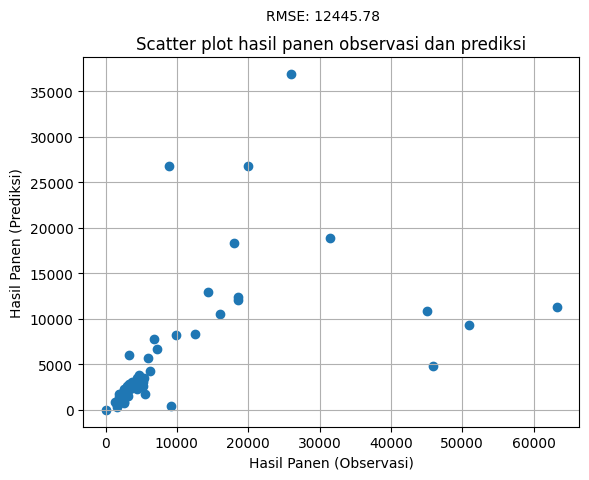

In [ ]:
import matplotlib.pyplot as plt
author_main.plot(y_pred, y_test)

### Split sensitivity / 分割による変動

The released code shuffles without a seed, so the RMSE depends on the draw. Three seeds show the expected variation range around the reported value. **著者コードは無シード shuffle のため、RMSE は分割に依存します。3 種類のシードで変動幅を確認します。**

In [ ]:
import pandas as pd
# Split-variance probe with a reduced budget (200 trees): the seed variation comes from the
# unseeded split, not from the scenario, so a smaller ensemble measures the same effect in
# ~1/10 of the time. The full 2000-tree scenario above takes about 13 minutes on CPU.
rows = []
for seed in (0, 1, 2):
    Xtr, Xte, ytr, yte = author_split(X, y, test_size=0.2, seed=seed)
    Xtr, Xte = author_main.standardization(Xtr, Xte)
    m = GradientBoostingRegressor(estimators=200, learning_rate=0.001, max_depth=4, min_samples_split=2)
    m.bar = lambda it: iter(it)
    m.fit(Xtr, ytr)
    rows.append({'seed': seed, 'RMSE_quintal_200trees': root_mean_squared_error(yte, m.predict(Xte))})
df = pd.DataFrame(rows)
print(df.to_string(index=False))
print('split sensitivity at 200 trees; full-scenario RMSE (2000 trees, seed 42) shown above')

 seed  RMSE_quintal_200trees
    0           12580.070838
    1           20167.354310
    2           15426.457094
split sensitivity at 200 trees; full-scenario RMSE (2000 trees, seed 42) shown above


## Interpretation and limitations / 解釈と限界

- The recomputed RMSE with the paper's best scenario is shown above; because the released code uses an **unseeded** 80/20 split, the value varies between runs, and the seed spread cell quantifies that variation. Agreement with the reported 9766.72 quintal within the observed spread is the expected outcome; an exact match is not expected for any single seed.
- **Scope:** one minimal example from the paper's published processed dataset. The ENVI/Landsat 8 acquisition and atmospheric-correction pipeline is not reproduced (requires ENVI + EarthExplorer credentials); the 90-scenario sweep is not run.
- **Author implementation quirks kept as-is:** `predict()` subtracts `min(y_pred)` from the ensemble output, and the custom regression tree uses variance-reduction splits — both are the authors' published behavior.
- **Provenance:** author code from GitHub commit `cb760d83…` (blob SHA-1 verified); data from OSF registration p9cy3 (`Dataset Final.xlsx`, sha256 verified, identical to the `data.csv` inside the author zip). Zenodo mirror: record 6459715, v1.0.0.
- Runtime: standard **CPU** Colab runtime, a few minutes total.

**日本語:** 本ノートブックは公開済みの処理後データセットから、著者実装の勾配ブースティングを最良シナリオで再学習する最小デモです。ENVI/Landsat 8 の前処理パイプラインと 90 シナリオ探索は対象外。著者実装特有の挙動（`predict` での min シフト、分散削減分割）はそのまま保持しています。無シード分割のため RMSE は実行ごとに変動します。

**References:** Riza, D.S. et al., F1000Research 11:682 (2022). Code: github.com/lala-s-riza/Remote-sensing-and-machine-learning-for-yield-prediction-of-lowland-paddy-crops (commit cb760d83). Data: OSF p9cy3.